# ECMWF-style 2 m temperature animation

This uses cleopatra's `temperature_2m` data-style — **ECMWF's actual default** (from earthkit-plots'
`2t.yml`): the muted **`Spectral_r`** colour ramp rendered as **discrete 2 °C contour bands** over −40…40 °C with
the out-of-range ends capped (`extend="both"`) — the look of a professional weather-service chart, not the neon
blue→magenta rainbow. (The generic `temperature` preset auto-ranges to the data instead; pass it `vmin`/`vmax`
to pin a non-Celsius field to a chosen range.)

The map is composed like an ECMWF chart: temperature bands + grey coastlines/borders + an arrow-capped colorbar
labelled with the contour levels, over the real ERA5-Land data (1 Jun – 15 Jul 2026).

In [1]:
import matplotlib

matplotlib.use("Agg")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from matplotlib.cm import ScalarMappable

import cleopatra.reference as ref
from cleopatra.animation import embed_gif
from cleopatra.colors import DATA_STYLES, resolve_style_norm

# --- data ---
npz = np.load(Path("../../../examples/data/europe_t2m.npz"), allow_pickle=True)
celsius = npz["celsius"][::2]  # every other day, 23 frames
labels = list(npz["labels"])[::2]
west, south, east, north = (float(v) for v in npz["extent"])
ext = [west, east, south, north]

# --- the style is the single source of truth for cmap + levels + extend ---
# "temperature_2m" is ECMWF's FIXED 2 m-temperature scale (Spectral_r banded over -40..40).
# The generic "temperature" preset auto-ranges to the data instead; pass it
# vmin/vmax to pin a non-Celsius field to a chosen range.
cfg = DATA_STYLES["temperature_2m"]["temperature_2m"]
cmap = plt.get_cmap(cfg["cmap"])
norm, vmin, vmax = resolve_style_norm(
    celsius[0], cfg
)  # BoundaryNorm over the 2 °C levels, extend='both'
levels = cfg["levels"]
print(
    "style:",
    cfg["cmap"],
    "| levels",
    levels[0],
    "..",
    levels[-1],
    "step",
    levels[1] - levels[0],
    "| extend",
    cfg["extend"],
)
print("stack:", celsius.shape, "| frames:", labels[0], "->", labels[-1])

style: Spectral_r | levels -40 .. 40 step 2 | extend both
stack: (23, 111, 164) | frames: Jun 01 -> Jul 15


## The animation

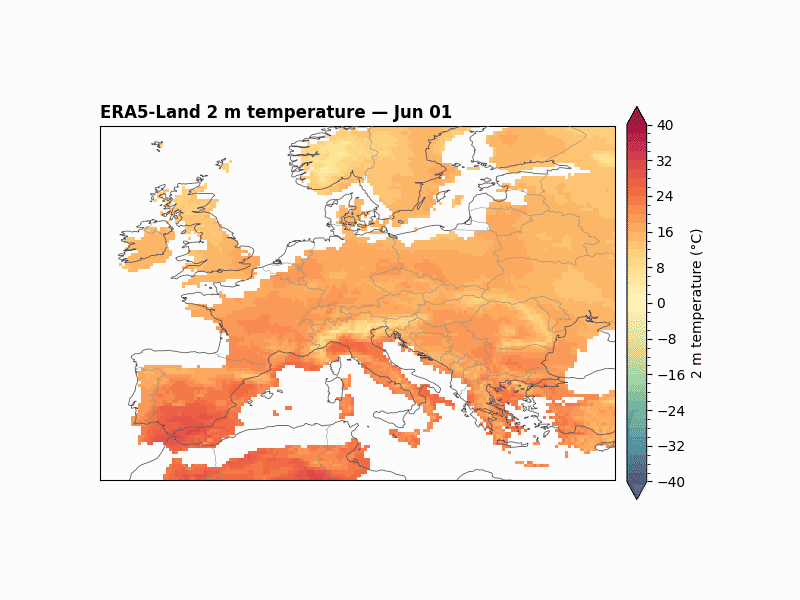

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(ext[0], ext[1])
ax.set_ylim(ext[2], ext[3])
ax.set_xticks([])
ax.set_yticks([])

# static reference layers (drawn once, on top of the data)
ref.add_features(ax, "coastline", "50m", color="0.35", linewidth=0.6, zorder=5)
ref.add_features(ax, "borders", "50m", color="0.55", linewidth=0.4, zorder=5)

# arrow-capped colorbar labelled with the contour levels (the ECMWF colorbar)
cbar = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    extend=cfg["extend"],
    ticks=levels[::4],
    shrink=0.85,
    pad=0.02,
)
cbar.set_label("2 m temperature (°C)")

state = {"im": None}


def update(i):
    if state["im"] is not None:
        state["im"].remove()
    state["im"] = ax.imshow(
        celsius[i],
        cmap=cmap,
        norm=norm,
        extent=ext,
        origin="upper",
        zorder=1,
    )
    ax.set_title(
        f"ERA5-Land 2 m temperature — {labels[i]}", loc="left", fontweight="bold"
    )
    return [state["im"]]


anim = FuncAnimation(fig, update, frames=len(celsius), interval=160)
embed_gif(anim, fps=6)

The exact same look is available in one call anywhere a cleopatra glyph is used —
`ArrayGlyph(data, extent=..., style="temperature_2m").plot()` / `.animate(...)` — because the `Spectral_r` ramp,
the 2 °C `levels`, and `extend="both"` are all baked into the `temperature_2m` style. For a field that is not fixed to
the ECMWF −40…40 °C window, use the generic `temperature` style (optionally with `vmin`/`vmax`), which
auto-ranges to the data.